In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
mall_customers = pd.read_csv("https://raw.githubusercontent.com/ammishra08/MachineLearning/master/Datasets/Mall_Customers.csv")

In [ ]:
mall_customers.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
mall_customers.shape

(200, 5)

In [ ]:
# Missing values
mall_customers.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

# EDA

In [ ]:
mall_customers['Gender'].value_counts()

Female    112
Male       88
Name: Gender, dtype: int64

<AxesSubplot:xlabel='Gender', ylabel='count'>

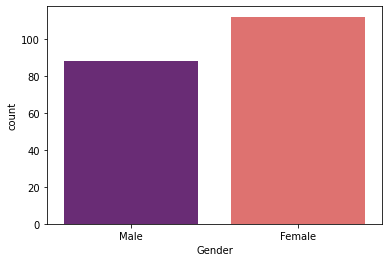

In [ ]:
sns.countplot(x = 'Gender', data = mall_customers, palette = 'magma')

<AxesSubplot:xlabel='Age', ylabel='count'>

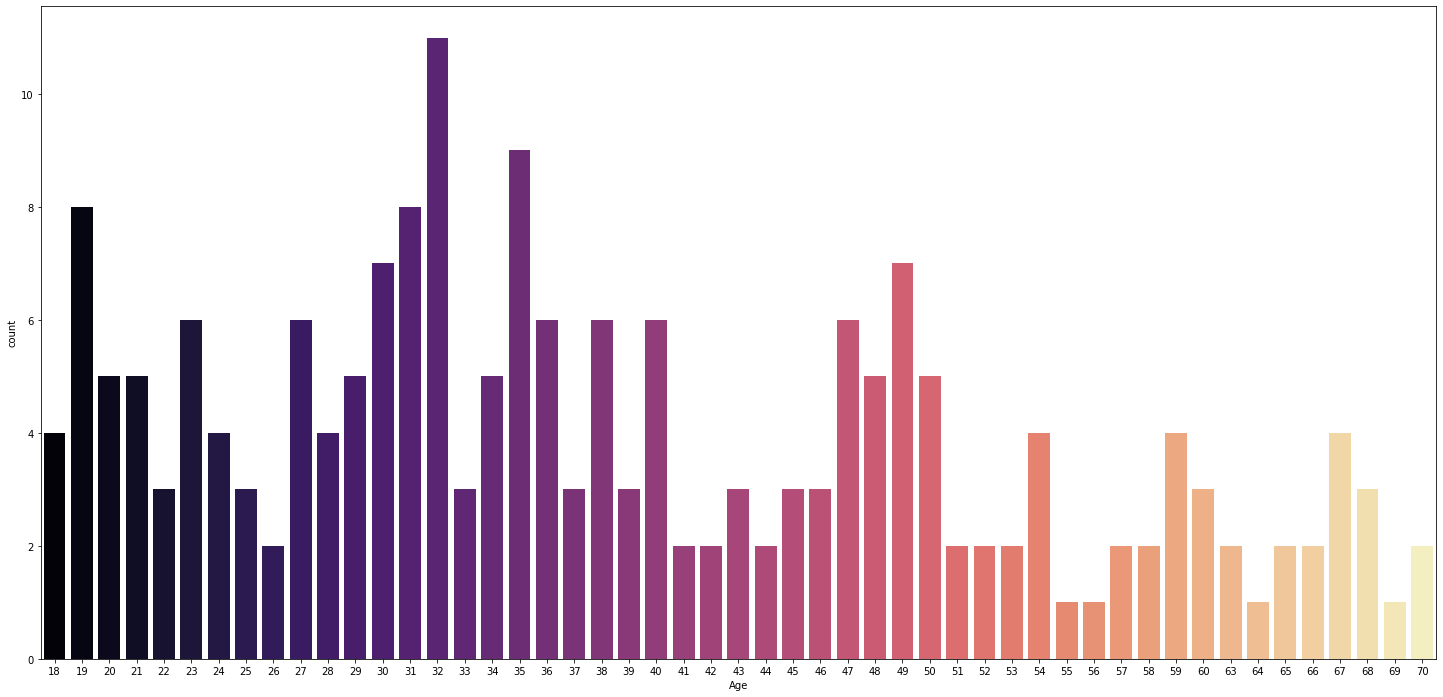

In [ ]:
# Frequency of each age
plt.figure (figsize = (25,12))
sns.countplot(x = 'Age', data = mall_customers, palette = 'magma')

<AxesSubplot:xlabel='Annual Income (k$)', ylabel='count'>

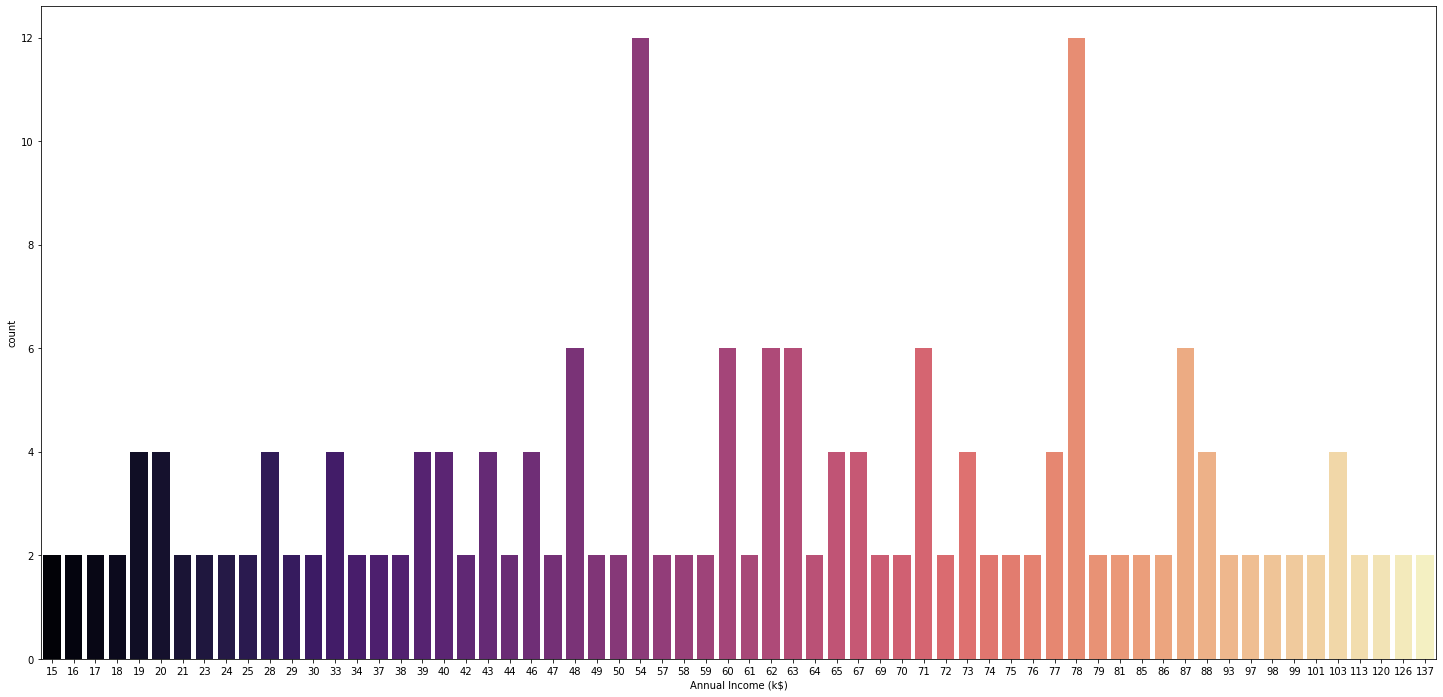

In [ ]:
# Frequency of Annual Income (k$)
plt.figure (figsize = (25,12))
sns.countplot(x = 'Annual Income (k$)', data = mall_customers,
              palette = 'magma')

## Features

In [ ]:
X = mall_customers.iloc[:,[3,4]]
X

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


## Elbow method

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
# Use elbow method to find optimal no of clusters
wcss = []
for i in range(1,16):
  kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300,
                  n_init = 10)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)

In [ ]:
wcss

[269981.28,
 181363.59595959593,
 106348.37306211122,
 73679.78903948836,
 44448.4554479337,
 37233.814510710006,
 30259.65720728547,
 25331.042318281467,
 22870.052118772095,
 19657.78360870395,
 17515.872164701657,
 15817.740201007091,
 14320.918182339483,
 13214.648506464298,
 11907.101070481242]

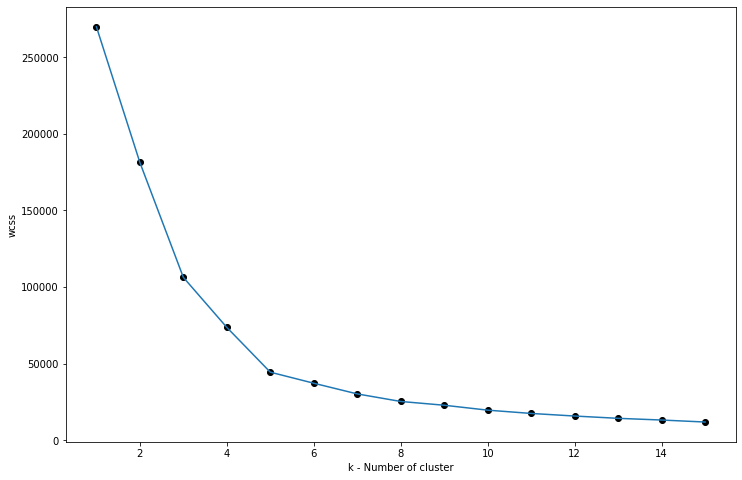

In [ ]:
plt.figure(figsize = (12,8))
plt.plot (range(1,16),wcss)
plt.scatter(range(1,16),wcss,marker = 'o', color = 'black')
plt.xlabel('k - Number of cluster')
plt.ylabel('wcss')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters = 5, init = 'k-means++', max_iter = 300, n_init = 10)
kmeans.fit(X)

KMeans(n_clusters=5, n_init=10)

In [ ]:
y_clusters = kmeans.predict(X)
y_clusters

array([4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0,
       4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 1,
       4, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 2, 3, 1, 3, 2, 3, 2, 3,
       1, 3, 2, 3, 2, 3, 2, 3, 2, 3, 1, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3,
       2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3,
       2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3,
       2, 3], dtype=int32)

In [ ]:
# Wcss value of K = 5
kmeans.inertia_

44448.4554479337

In [ ]:
kmeans.cluster_centers_

array([[25.72727273, 79.36363636],
       [55.2962963 , 49.51851852],
       [88.2       , 17.11428571],
       [86.53846154, 82.12820513],
       [26.30434783, 20.91304348]])

# Cluster Visualization

In [ ]:
y_clusters.astype

<function ndarray.astype>

In [ ]:
x_array = np.array(X)
x_array.astype

<function ndarray.astype>

/usr/local/lib/python3.9/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


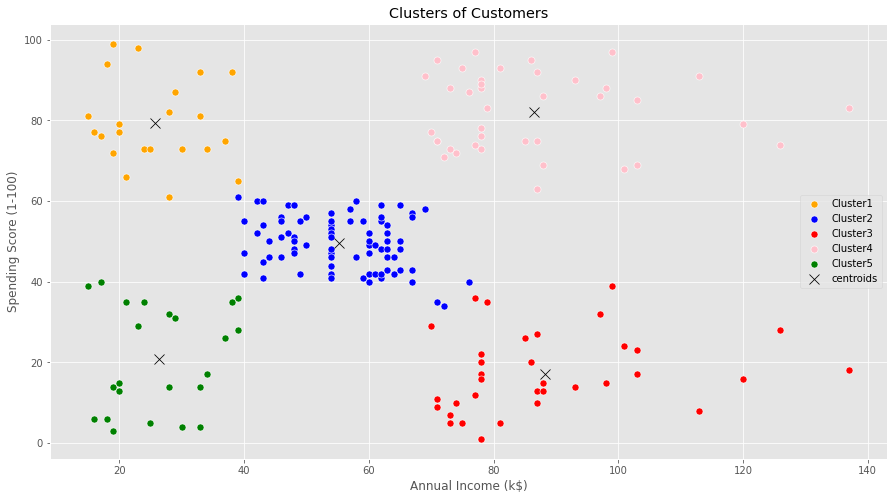

In [ ]:
#visulization of cluster
plt.style.use('ggplot')
plt.figure(figsize = (15,8))
sns.scatterplot(x = x_array[y_clusters == 0,0], y = x_array[y_clusters == 0,1],
                color = 'orange', label = 'Cluster1', s=50)
sns.scatterplot(x = x_array[y_clusters == 1,0], y = x_array[y_clusters == 1,1],
                color = 'blue', label = 'Cluster2', s=50)
sns.scatterplot(x = x_array[y_clusters == 2,0], y = x_array[y_clusters == 2,1],
                color = 'red', label = 'Cluster3', s=50)
sns.scatterplot(x = x_array[y_clusters == 3,0], y = x_array[y_clusters == 3,1],
                color = 'pink', label = 'Cluster4', s=50)
sns.scatterplot(x = x_array[y_clusters == 4,0], y = x_array[y_clusters == 4,1],
                color = 'green', label = 'Cluster5', s=50)
sns.scatterplot(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],
                marker = 'x',color = 'black', label = 'centroids', s = 100)
plt.title("Clusters of Customers")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()